start data transformation


In [1]:
%pwd
%cd /home/jovyan/work/results/Cell/
%pwd

/home/jovyan/work/results/Cell


'/home/jovyan/work/results/Cell'

In [2]:
import scanpy as sc
import scanpy.external as sce
import leidenalg
import numpy as np

In [4]:
adata = sc.read("raw.h5ad")
adata

AnnData object with n_obs × n_vars = 152182 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'scrublet'

Normalize counts per cell.
Normalize each cell by total counts over all genes, so that every cell has the same total count after normalization. If choosing target_sum=1e6, this is CPM normalization.

In [5]:
sc.pp.normalize_total(adata, target_sum=1e4)
adata

AnnData object with n_obs × n_vars = 152182 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'scrublet'

In [6]:
adata.write("normalized.h5ad")

log(1+p) transformation to condense the sparse expression distribution

In [7]:
sc.pp.log1p(adata)
adata

AnnData object with n_obs × n_vars = 152182 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'scrublet', 'log1p'

In [8]:
adata.uns  # {'base': None} is very important for hvgs functions

{'scrublet': {'batched_by': 'sample_ID',
  'batches': {'T162': {'doublet_parents': array([[13865, 13596],
           [ 8619,  9855],
           [ 7865,  6117],
           ...,
           [ 6027,   561],
           [ 9655,  2179],
           [   95,  6860]]),
    'doublet_scores_sim': array([0.17047817, 0.14414414, 0.06467181, ..., 0.06150979, 0.17047817,
           0.14414414]),
    'parameters': {'expected_doublet_rate': 0.05,
     'n_neighbors': 61,
     'random_state': 0,
     'sim_doublet_ratio': 2.0},
    'threshold': 0.39017573461345434},
   'T175': {'doublet_parents': array([[13308, 11472],
           [ 8273,  4566],
           [ 7549,  5520],
           ...,
           [10118,  7759],
           [11997, 12834],
           [10542,  7250]]),
    'doublet_scores_sim': array([0.14874552, 0.14874552, 0.24964739, ..., 0.44794189, 0.18367347,
           0.18367347]),
    'parameters': {'expected_doublet_rate': 0.05,
     'n_neighbors': 63,
     'random_state': 0,
     'sim_doublet_rat

In [9]:
adata.write("log1p.h5ad")

lets try not to regress out first, since it contains many different cell types. regress out works when cell types are highly similar.
consulting to https://www.jianshu.com/p/4530d2955562 , https://github.com/scverse/scanpy/issues/526 
Regress out (mostly) unwanted sources of variation.
including number of detected genes, mt-ratio

let's select hvgs first, although the expression has batch effect, harmony algorithm needs PCA to be computed first. Besides, harmony algorithm doesn't alter expression, so it's fine to select hvgs first for later PCA computation in order to save time.

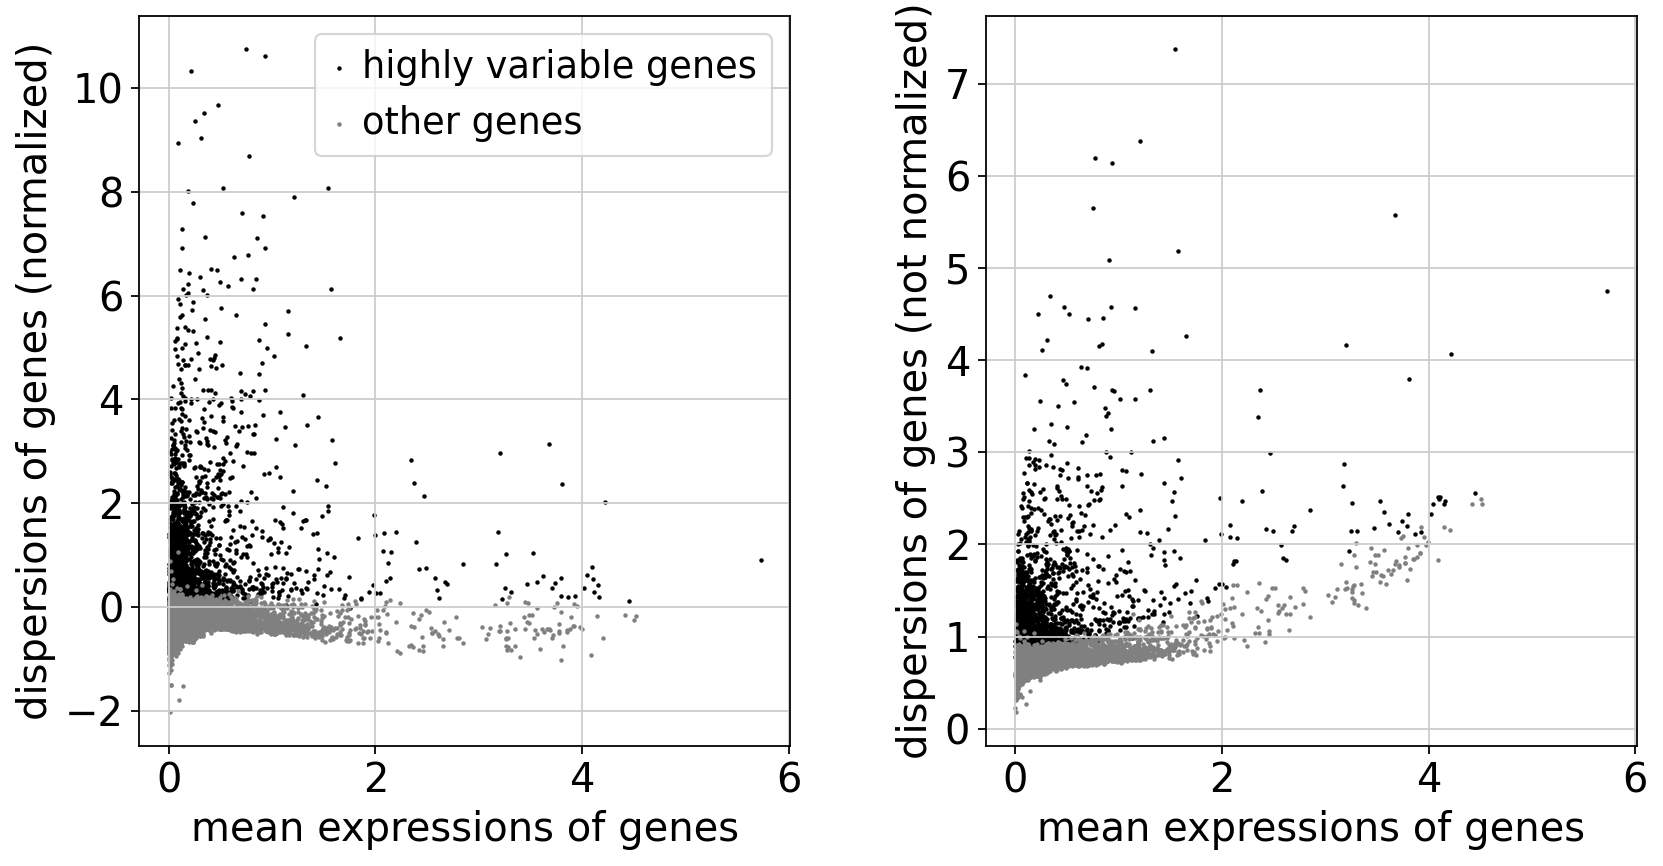

AnnData object with n_obs × n_vars = 152182 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'scrublet', 'log1p', 'hvg'

In [10]:
# if there's error, consult to https://github.com/scverse/scanpy/issues/2239
# in brief, do not read adata from .h5ad file, process the whole file from top to bottom,
# because saving in .h5ad corrups adata.uns
# Expects logarithmized data, except when flavor='seurat_v3', in which count data is expected.
sc.set_figure_params(fontsize=18, figsize="6,6")
# sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=5, min_disp=0.3, batch_key='sample_ID')
sc.pp.highly_variable_genes(adata, n_top_genes=2500, batch_key='sample_ID')
sc.pl.highly_variable_genes(adata, save=".svg")
adata

In [11]:
adata[:,adata.var["highly_variable"]==True].shape

(152182, 2500)

In [12]:
adata.X

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        2.14075975],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        1.83835843],
       [0.        , 0.        , 1.03862062, ..., 0.        , 0.        ,
        2.11640835],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.01470553, 0.        , ..., 0.        , 0.63088632,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.62005631]])

In [13]:
adata.write("hvgs.h5ad")

scale the data to represent z-values of expression for all genes

Scale each gene to unit variance. Clip values exceeding standard deviation 10.

In [14]:
sc.pp.scale(adata, max_value=10)
adata

AnnData object with n_obs × n_vars = 152182 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'scrublet', 'log1p', 'hvg'

In [15]:
adata.X  # scaling succeed

array([[-0.27927253, -0.45120853, -0.20008144, ..., -0.13102259,
        -0.10337624,  0.99804155],
       [-0.27927253, -0.45120853, -0.20008144, ..., -0.13102259,
        -0.10337624,  0.74484462],
       [-0.27927253, -0.45120853,  5.30915726, ..., -0.13102259,
        -0.10337624,  0.97765242],
       ...,
       [-0.27927253, -0.45120853, -0.20008144, ..., -0.13102259,
        -0.10337624, -0.79439044],
       [-0.27927253,  2.07764513, -0.20008144, ..., -0.13102259,
         9.09764457, -0.79439044],
       [-0.27927253, -0.45120853, -0.20008144, ..., -0.13102259,
        -0.10337624, -0.27522486]])

the original data's mean and std

In [16]:
adata.var["mean"]

Symbol
TSPAN6       0.074512
DPM1         0.181048
SCYL3        0.037720
C1orf112     0.025499
FGR          0.018595
               ...   
LINC01481    0.059301
CYB561D2     0.091717
CCDC7        0.015357
MATR3        0.007088
RGS5         0.948766
Name: mean, Length: 12939, dtype: float64

In [17]:
adata.var["std"]

Symbol
TSPAN6       0.266808
DPM1         0.401251
SCYL3        0.188523
C1orf112     0.153750
FGR          0.158651
               ...   
LINC01481    0.202864
CYB561D2     0.278621
CCDC7        0.117207
MATR3        0.068567
RGS5         1.194332
Name: std, Length: 12939, dtype: float64

In [18]:
# the data is both scaled and clipped
adata.write("clipped.h5ad")

In [19]:
# adata = adata[:, adata.var.highly_variable]
# adata
# # hvg_data = adata[:, adata.var.highly_variable].copy()
# # hvg_data

In [20]:
# adata.write("hvgs.h5ad")

In [21]:
# # test
# tdata = sc.read("hvgs.h5ad")
# np.array_equal(tdata.X, adata.X)

PCA

In [19]:
sc.tl.pca(adata, svd_solver='arpack', use_highly_variable=True)
adata

/opt/conda/envs/the-project/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:374: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


AnnData object with n_obs × n_vars = 152182 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'scrublet', 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

just take a look on how a gene's expression is distributed across PCs

In [20]:
adata.var_names

Index(['TSPAN6', 'DPM1', 'SCYL3', 'C1orf112', 'FGR', 'FUCA2', 'GCLC', 'NFYA',
       'STPG1', 'NIPAL3',
       ...
       'SEPSECS-AS1', 'LINC01144', 'ADORA3', 'BISPR', 'PRNCR1', 'LINC01481',
       'CYB561D2', 'CCDC7', 'MATR3', 'RGS5'],
      dtype='object', name='Symbol', length=12939)

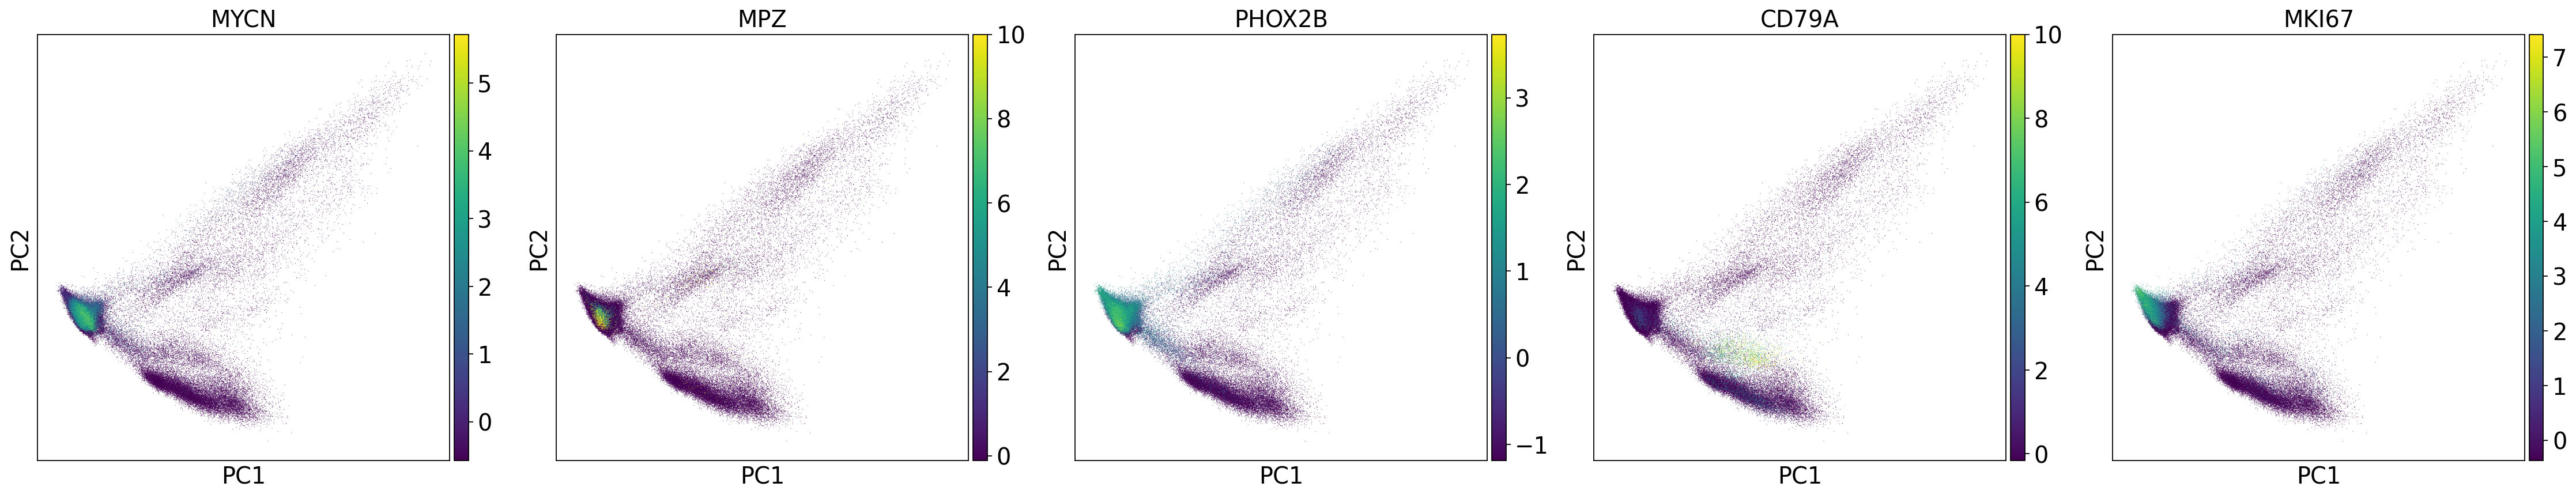

In [21]:
# markers for NB, SCPs, NE-cells, B-cells, and cell cycle
sc.pl.pca(adata, color=["MYCN", "MPZ", "PHOX2B", "CD79A", "MKI67"], ncols=5, save="_markers.svg")

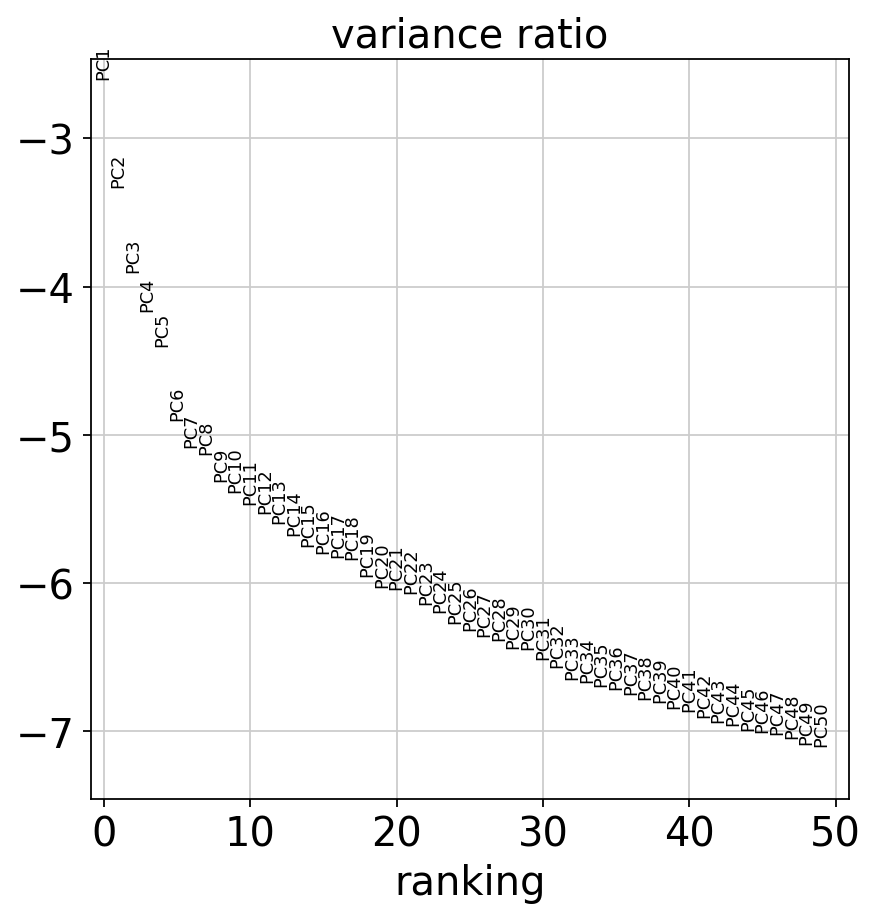

In [22]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True, save=".svg")

save the file

In [23]:
adata.write("pca.h5ad")
adata

AnnData object with n_obs × n_vars = 152182 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'scrublet', 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

remove batch effect using harmony

In [24]:
sce.pp.harmony_integrate(adata, key='sample_ID')
adata

2024-07-22 10:45:38,247 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2024-07-22 10:45:48,056 - harmonypy - INFO - sklearn.KMeans initialization complete.
2024-07-22 10:45:49,483 - harmonypy - INFO - Iteration 1 of 10
2024-07-22 10:46:35,477 - harmonypy - INFO - Iteration 2 of 10
2024-07-22 10:47:22,483 - harmonypy - INFO - Iteration 3 of 10
2024-07-22 10:48:09,854 - harmonypy - INFO - Iteration 4 of 10
2024-07-22 10:48:56,689 - harmonypy - INFO - Iteration 5 of 10
2024-07-22 10:49:43,614 - harmonypy - INFO - Converged after 5 iterations


AnnData object with n_obs × n_vars = 152182 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'scrublet', 'log1p', 'hvg', 'pca'
    obsm: 'X_pca', 'X_pca_harmony'
    varm: 'PCs'

In [25]:
adata.write("batch_effect_removed_harmony.h5ad")

Computing the neighborhood graph

Updates adata with the field adata.obsm[obsm_out_field], containing principal components adjusted by Harmony such that different experiments are integrated.

In [26]:
# use_rep='X_pca_harmony' denotes I'm using corrected PCA to compute neighbors
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50, use_rep='X_pca_harmony')
adata

AnnData object with n_obs × n_vars = 152182 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'scrublet', 'log1p', 'hvg', 'pca', 'neighbors'
    obsm: 'X_pca', 'X_pca_harmony'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

Embedding the neighborhood graph

You need to run `tl.leiden` or `tl.louvain` to compute community labels, or specify `groups='an_existing_key'`

In [27]:
sc.tl.leiden(adata)
adata

/tmp/ipykernel_21198/3520793330.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


AnnData object with n_obs × n_vars = 152182 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'leiden'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'scrublet', 'log1p', 'hvg', 'pca', 'neighbors', 'leiden'
    obsm: 'X_pca', 'X_pca_harmony'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

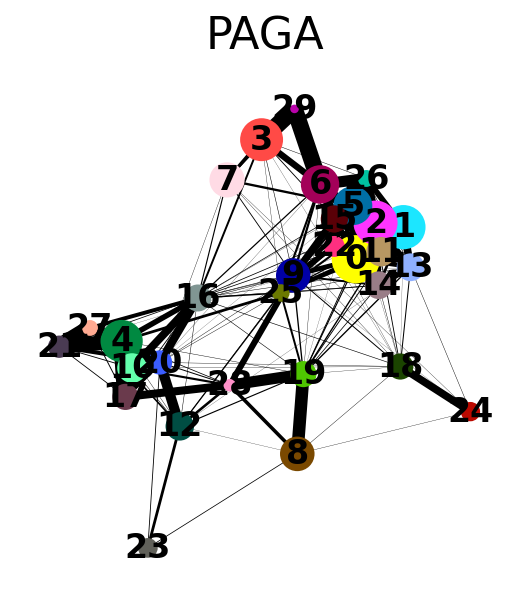

AnnData object with n_obs × n_vars = 152182 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'leiden'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'scrublet', 'log1p', 'hvg', 'pca', 'neighbors', 'leiden', 'paga', 'leiden_sizes', 'leiden_colors'
    obsm: 'X_pca', 'X_pca_harmony'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [28]:
# paga requires leiden or louvain to run first, because it is a TI algorithm which uses clusters to infer trajectories
sc.tl.paga(adata)
sc.set_figure_params(fontsize=20)
sc.pl.paga(adata, frameon=False, title="PAGA", fontsize=15, save=".svg")  # remove `plot=False` if you want to see the coarse-grained graph
adata

Note that you can use the result of paga() in umap() and draw_graph() via init_pos='paga' to get single-cell embeddings that are typically more faithful to the global topology.

In [29]:
# sc.tl.umap(adata)
# use the paga embedding
sc.tl.umap(adata, init_pos='paga')
adata

AnnData object with n_obs × n_vars = 152182 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'leiden'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'scrublet', 'log1p', 'hvg', 'pca', 'neighbors', 'leiden', 'paga', 'leiden_sizes', 'leiden_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

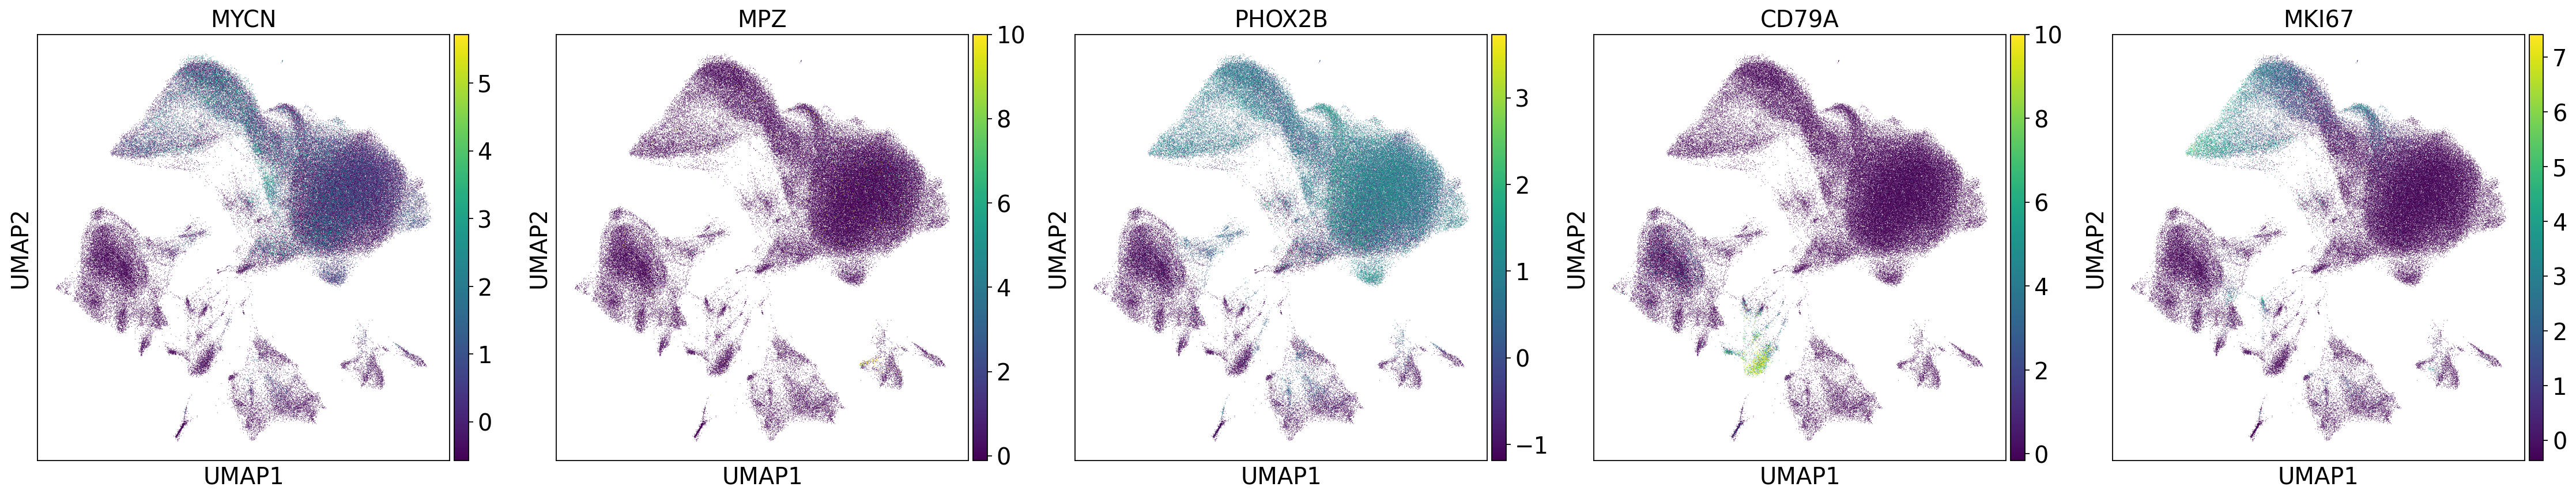

In [30]:
sc.set_figure_params(fontsize=18, figsize="6,6")
sc.pl.umap(adata, color=["MYCN", "MPZ", "PHOX2B", "CD79A", "MKI67"], ncols=5, save="_markers.svg")

Clustering the neighborhood graph

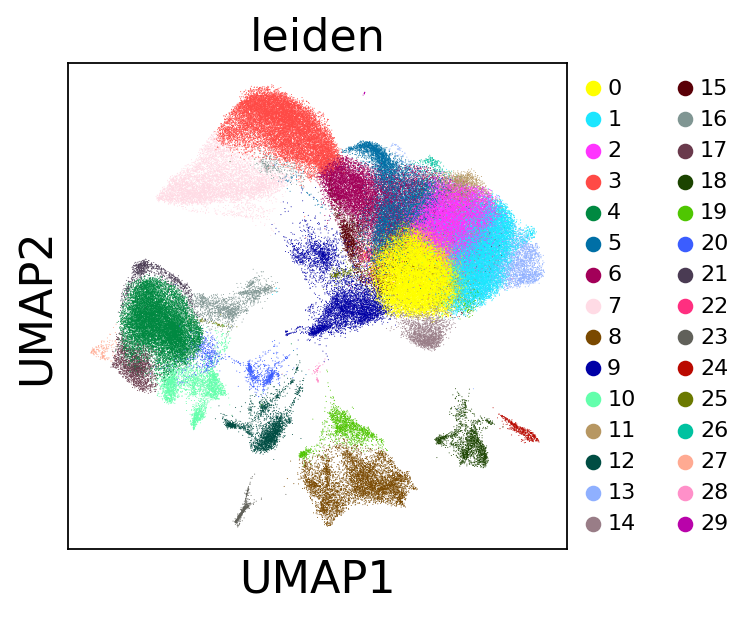

In [31]:
sc.set_figure_params(fontsize=20, figsize=None)
sc.pl.umap(adata, color=['leiden'], legend_fontsize=10, save="_leiden.svg")

In [32]:
adata.write("leiden.h5ad")

In [33]:
adata

AnnData object with n_obs × n_vars = 152182 × 12939
    obs: 'sample_ID', 'Gender', 'INSS_stage', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'leiden'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'scrublet', 'log1p', 'hvg', 'pca', 'neighbors', 'leiden', 'paga', 'leiden_sizes', 'leiden_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

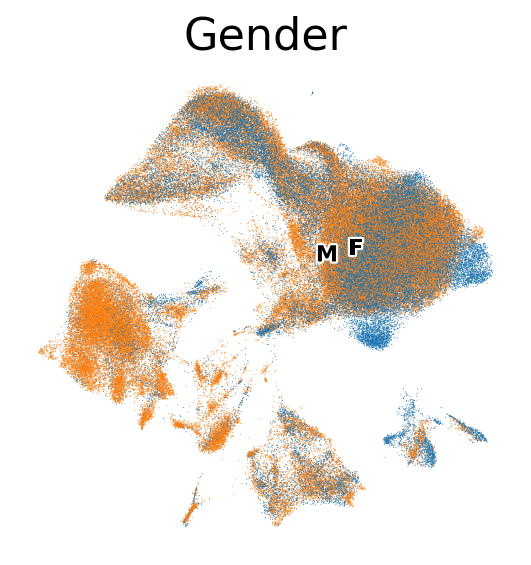

In [37]:
sc.pl.umap(adata, color='Gender', legend_loc='on data',
           frameon=False, legend_fontsize=10, legend_fontoutline=2, save="_sample_source.svg")

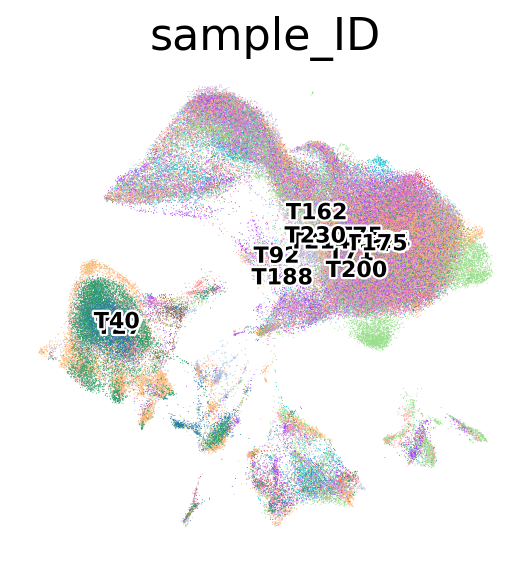

In [34]:
sc.pl.umap(adata, color='sample_ID', legend_loc='on data',
           frameon=False, legend_fontsize=10, legend_fontoutline=2, save="_sample_id.svg")

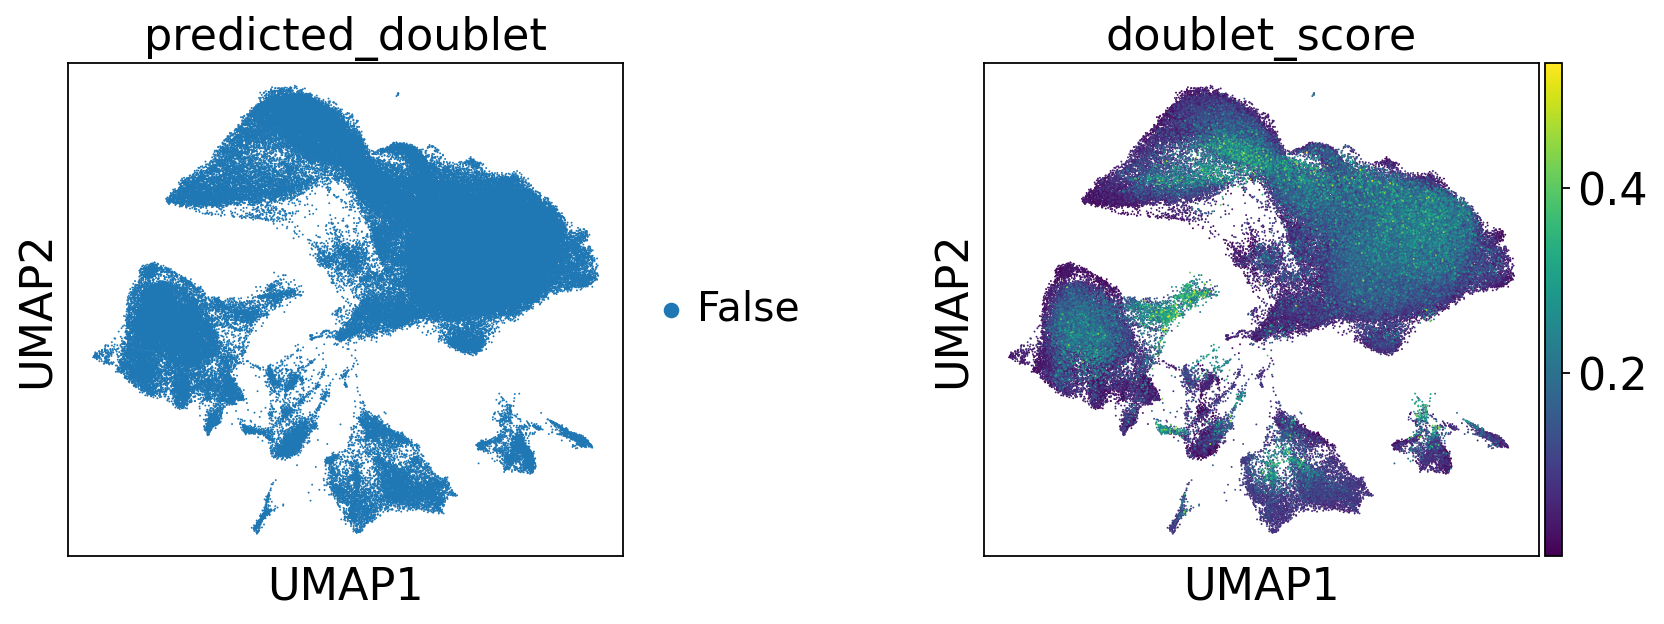

In [35]:
sc.pl.umap(
    adata,
    color=["predicted_doublet", "doublet_score"],
    # increase horizontal space between panels
    wspace=0.5,
    size=3,
    save="_doublet.svg"
)

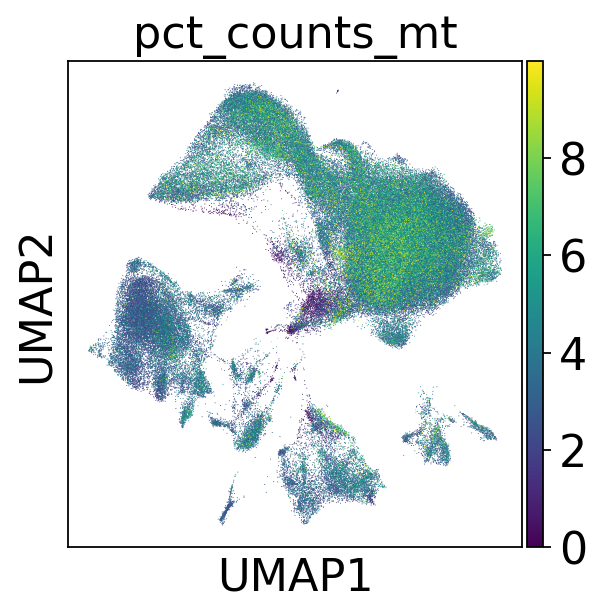

In [36]:
sc.pl.umap(
    adata,
    color=["pct_counts_mt"],
    wspace=0.5,
    ncols=2,
    save="_pct_counts_mt.svg"
)